In [1]:
# ==========================================================
# Import Libraries
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ==========================================================
# Create Dataset
# ==========================================================
data = {
    "Area":[1000,1200,1500,1800,2000,2200,2500,2700,3000,3500],
    "Bedrooms":[2,2,3,3,4,4,4,5,5,6],
    "HousePrice":[200000,230000,280000,330000,380000,
                  420000,470000,520000,580000,650000]
}

df = pd.DataFrame(data)

df

,Area,Bedrooms,HousePrice
0,1000,2,200000
1,1200,2,230000
2,1500,3,280000
3,1800,3,330000
4,2000,4,380000
5,2200,4,420000
6,2500,4,470000
7,2700,5,520000
8,3000,5,580000
9,3500,6,650000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Area        10 non-null     int64
 1   Bedrooms    10 non-null     int64
 2   HousePrice  10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [4]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
HousePrice,0


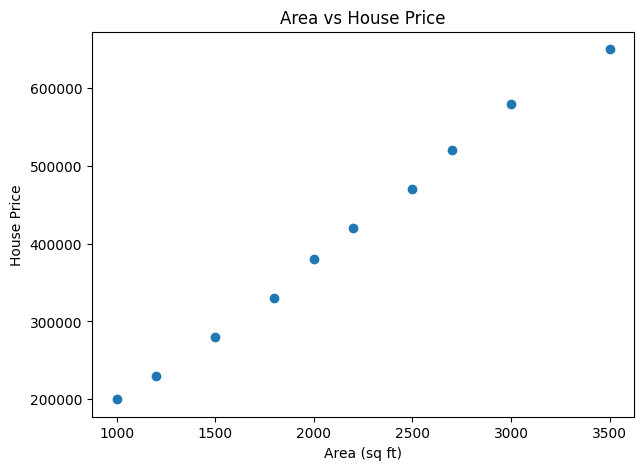

In [5]:
# ==========================================================
# Scatter Plot
# ==========================================================
plt.figure(figsize=(7,5))

plt.scatter(df["Area"],df["HousePrice"])

plt.xlabel("Area (sq ft)")
plt.ylabel("House Price")
plt.title("Area vs House Price")

plt.show()

In [6]:
X = df[["Area","Bedrooms"]]

y = df["HousePrice"]

In [7]:
X

,Area,Bedrooms
0,1000,2
1,1200,2
2,1500,3
3,1800,3
4,2000,4
5,2200,4
6,2500,4
7,2700,5
8,3000,5
9,3500,6


In [8]:
y

,HousePrice
0,200000
1,230000
2,280000
3,330000
4,380000
5,420000
6,470000
7,520000
8,580000
9,650000


In [9]:
# ==========================================================
# Feature Scaling
# ==========================================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
X_scaled

array([[-1.5015606 , -1.44115338],
       [-1.23812892, -1.44115338],
       [-0.84298139, -0.64051262],
       [-0.44783386, -0.64051262],
       [-0.18440218,  0.16012815],
       [ 0.07902951,  0.16012815],
       [ 0.47417703,  0.16012815],
       [ 0.73760872,  0.96076892],
       [ 1.13275625,  0.96076892],
       [ 1.79133546,  1.76140969]])

In [11]:
# ==========================================================
# Train Test Split
# ==========================================================
X_train,X_test,y_train,y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [12]:
X_train

array([[ 0.07902951,  0.16012815],
       [-1.5015606 , -1.44115338],
       [ 0.73760872,  0.96076892],
       [-0.84298139, -0.64051262],
       [ 1.79133546,  1.76140969],
       [-0.18440218,  0.16012815],
       [-0.44783386, -0.64051262],
       [ 0.47417703,  0.16012815]])

In [13]:
X_test

array([[ 1.13275625,  0.96076892],
       [-1.23812892, -1.44115338]])

In [14]:
y_train

,HousePrice
5,420000
0,200000
7,520000
2,280000
9,650000
4,380000
3,330000
6,470000


In [15]:
y_test

,HousePrice
8,580000
1,230000


In [16]:
# ==========================================================
# Train Model
# ==========================================================
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [17]:
# ==========================================================
# Predictions
# ==========================================================
y_pred = model.predict(X_test)

In [18]:
# ==========================================================
# Evaluation
# ==========================================================
print("R2 Score :",r2_score(y_test,y_pred))

print("MSE :",mean_squared_error(y_test,y_pred))

R2 Score : 0.9934145712396742
MSE : 201678755.78497642


In [19]:
import warnings
warnings.filterwarnings("ignore")

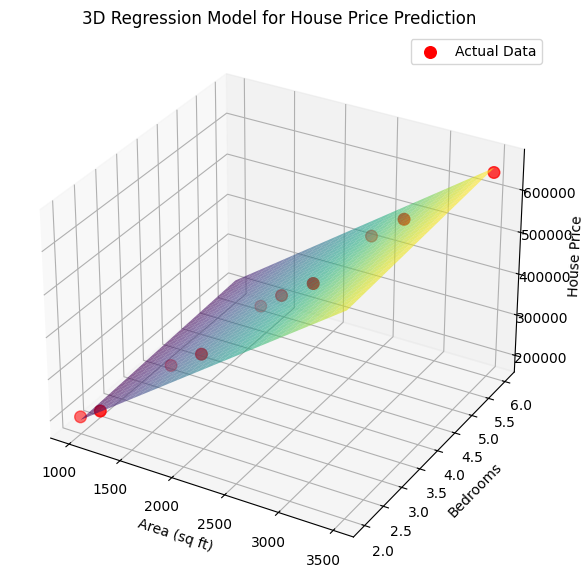

In [20]:
# ==========================================================
# 3D Regression Plot
# ==========================================================
# Create another model using original values for visualization
model_3d = LinearRegression()

model_3d.fit(X,y)

# Mesh Grid
area = np.linspace(df.Area.min(),df.Area.max(),30)

bedrooms = np.linspace(df.Bedrooms.min(),df.Bedrooms.max(),30)

Area_mesh,Bedroom_mesh = np.meshgrid(area,bedrooms)

Price_mesh = model_3d.predict(
    np.c_[Area_mesh.ravel(),Bedroom_mesh.ravel()]
)

Price_mesh = Price_mesh.reshape(Area_mesh.shape)

# 3D Plot
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111,projection='3d')

# Actual Data
ax.scatter(
    df.Area,
    df.Bedrooms,
    df.HousePrice,
    color='red',
    s=70,
    label="Actual Data"
)

# Regression Plane
ax.plot_surface(
    Area_mesh,
    Bedroom_mesh,
    Price_mesh,
    cmap="viridis",
    alpha=0.6
)

ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("House Price")

ax.set_title("3D Regression Model for House Price Prediction")

ax.legend()

plt.show()

In [21]:
# ==========================================================
# Save Model
# ==========================================================
import joblib

joblib.dump(model,"HousePrice_Model.pkl")

joblib.dump(scaler,"Scaler.pkl")

['Scaler.pkl']

In [22]:
# ==========================================================
# Load Model & Predict
# ==========================================================
model = joblib.load("HousePrice_Model.pkl")

scaler = joblib.load("Scaler.pkl")

# Area, Bedrooms
new_house = [[2400,4]]

new_house_scaled = scaler.transform(new_house)

prediction = model.predict(new_house_scaled)

print("Predicted House Price : ",prediction[0])

Predicted House Price :  448867.92452830187
